# Chapter 7 — Multi-Head, Grouped-Query, and Multi-Query Attention

Every modern transformer uses some variant of scaled dot-product attention, but the
architecture of how Q, K, and V projections are shared has evolved substantially:

| Variant | K/V heads | KV params (relative) | Used in |
|---|---|---|---|
| **MHA** | = Q heads | 1× | Original Transformer, BERT, GPT-2 |
| **GQA** | < Q heads | < 1× | LLaMA 2/3, Mistral, Gemma |
| **MQA** | 1 | minimal | PaLM, Falcon |

The core motivation is **KV-cache memory**: at inference, K and V tensors for every
past token must be stored. Reducing the number of KV heads shrinks this cache linearly.

This chapter implements both from scratch:
- `MultiHeadAttention` — explicit matmul, exposes attention weights for visualisation
- `GroupedQueryAttention` — uses `F.scaled_dot_product_attention`; covers GQA and MQA

**Prerequisites:** Ch-05 (RoPE).

In [1]:
import math
import matplotlib.pyplot as plt
import torch
from transformer_book_lab.multi_head_attention import MultiHeadAttention
from transformer_book_lab.grouped_query_attention import GroupedQueryAttention
from transformer_book_lab.rope import build_rope_cache

torch.manual_seed(42)
D_MODEL   = 64
NUM_HEADS = 8
BATCH     = 1
SEQ       = 12

x = torch.randn(BATCH, SEQ, D_MODEL)
print(f"Input shape: {x.shape}")

Input shape: torch.Size([1, 12, 64])


## 1 · Multi-Head Attention

MHA projects Q, K, V independently into `num_heads` subspaces of size
`head_dim = d_model // num_heads`, computes attention in each subspace,
then concatenates and projects back.

The explicit matmul `(Q @ Kᵀ / √head_dim) → softmax → (· V)` lets us
inspect the per-head attention distribution.

In [2]:
mha = MultiHeadAttention(D_MODEL, NUM_HEADS, dropout=0.0)
mha.eval()

with torch.no_grad():
    out_mha, weights = mha(x, x, x)   # self-attention

print(f"Output shape:          {out_mha.shape}")   # (1, 12, 64)
print(f"Attention weights:      {weights.shape}")  # (1, 8, 12, 12)
print(f"Weights sum along keys: {weights.sum(-1).mean().item():.4f}")  # ~1.0

Output shape:          torch.Size([1, 12, 64])
Attention weights:      torch.Size([1, 8, 12, 12])
Weights sum along keys: 1.0000


C:\Users\fpere\AppData\Local\Temp\claude\ipykernel_25628\888123418.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


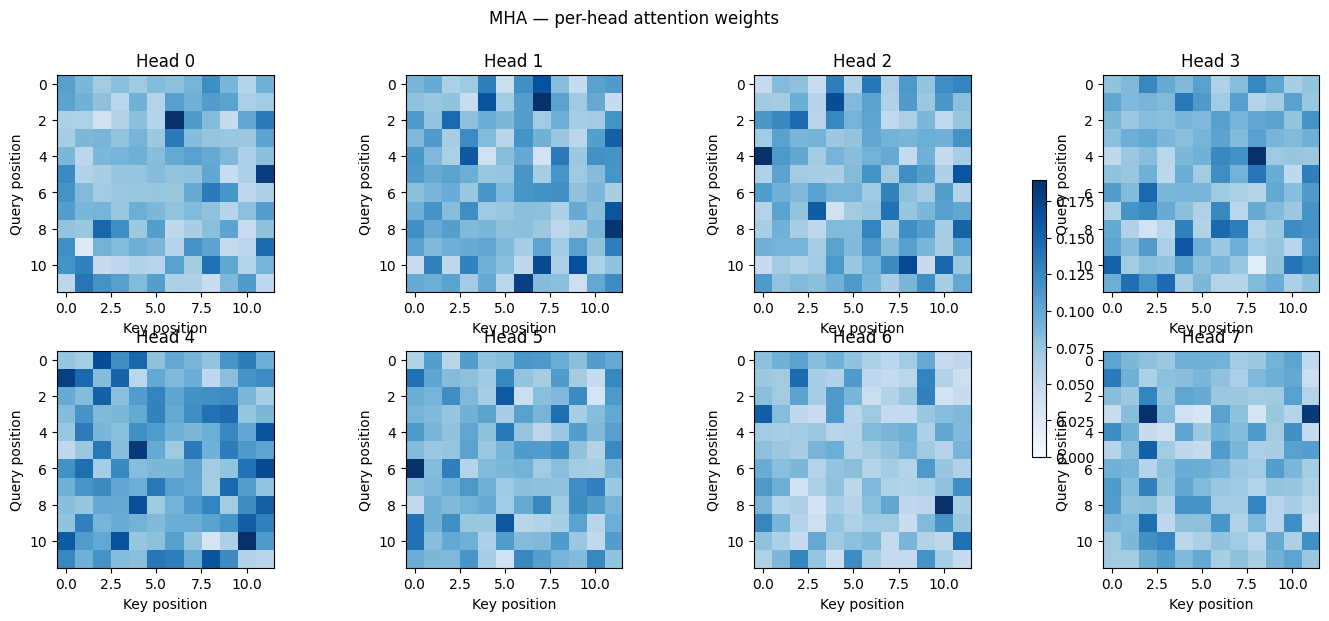

In [3]:
# Visualise per-head attention heatmaps
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
w = weights[0].detach().numpy()  # (8, 12, 12)
for h, ax in enumerate(axes.flat):
    im = ax.imshow(w[h], cmap="Blues", vmin=0, vmax=w[h].max())
    ax.set_title(f"Head {h}")
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
fig.colorbar(im, ax=axes, shrink=0.6)
plt.suptitle("MHA — per-head attention weights", y=1.01)
plt.tight_layout()
plt.show()

## 2 · Grouped-Query Attention

GQA introduces `num_kv_heads < num_heads`. Each group of
`groups = num_heads // num_kv_heads` query heads shares one K/V head pair.

Implementation detail: after projecting K and V to
`(batch, num_kv_heads, seq, head_dim)`, we expand them to
`(batch, num_heads, seq, head_dim)` via `repeat_interleave(groups, dim=1)`,
then pass to `F.scaled_dot_product_attention`.

In [4]:
gqa = GroupedQueryAttention(D_MODEL, NUM_HEADS, num_kv_heads=2, dropout=0.0)
gqa.eval()

with torch.no_grad():
    out_gqa = gqa(x, x, x)

print(f"GQA output shape: {out_gqa.shape}")

# Compare projection sizes vs MHA
head_dim = D_MODEL // NUM_HEADS
print()
print(f"  MHA  q_proj: {D_MODEL}×{D_MODEL}  k_proj: {D_MODEL}×{D_MODEL}")
print(f"  GQA  q_proj: {D_MODEL}×{D_MODEL}  k_proj: {2*head_dim}×{D_MODEL}  (num_kv_heads=2)")
print(f"  GQA  k_proj in/out: {gqa.k_proj.weight.shape}")

GQA output shape: torch.Size([1, 12, 64])

  MHA  q_proj: 64×64  k_proj: 64×64
  GQA  q_proj: 64×64  k_proj: 16×64  (num_kv_heads=2)
  GQA  k_proj in/out: torch.Size([16, 64])


## 3 · Multi-Query Attention

MQA is GQA with `num_kv_heads=1` — all query heads share a **single** K/V head.
This achieves the maximum KV-cache savings at the cost of representational capacity.

In [5]:
mqa = GroupedQueryAttention(D_MODEL, NUM_HEADS, num_kv_heads=1, dropout=0.0)
mqa.eval()

with torch.no_grad():
    out_mqa = mqa(x, x, x)

print(f"MQA output shape: {out_mqa.shape}")
print(f"MQA k_proj: {mqa.k_proj.weight.shape}  (only {head_dim} output dims)")

MQA output shape: torch.Size([1, 12, 64])
MQA k_proj: torch.Size([8, 64])  (only 8 output dims)


## 4 · Parameter Count Comparison

The KV projection accounts for most of the attention memory cost at inference.
Here we compare total attention parameters across MHA, GQA, and MQA for the
same `d_model` and `num_heads`.

In [6]:
def count_params(m: torch.nn.Module) -> int:
    return sum(p.numel() for p in m.parameters())

configs = [
    ("MHA  (num_kv=8)", MultiHeadAttention(D_MODEL, NUM_HEADS)),
    ("GQA  (num_kv=4)", GroupedQueryAttention(D_MODEL, NUM_HEADS, 4)),
    ("GQA  (num_kv=2)", GroupedQueryAttention(D_MODEL, NUM_HEADS, 2)),
    ("MQA  (num_kv=1)", GroupedQueryAttention(D_MODEL, NUM_HEADS, 1)),
]

header = f"{'Variant':<22} {'Total params':>14} {'KV params':>12} {'KV %':>8}"
print(header)
print("-" * 60)
for name, mod in configs:
    total = count_params(mod)
    kv = mod.k_proj.weight.numel() + mod.v_proj.weight.numel()
    kv_pct = 100 * kv / total
    print(f"{name:<22} {total:>14,} {kv:>12,} {kv_pct:>7.1f}%")

Variant                  Total params    KV params     KV %
------------------------------------------------------------
MHA  (num_kv=8)                16,384        8,192    50.0%
GQA  (num_kv=4)                12,288        4,096    33.3%
GQA  (num_kv=2)                10,240        2,048    20.0%
MQA  (num_kv=1)                 9,216        1,024    11.1%


## 5 · RoPE Integration

Both modules accept an optional `(cos, sin)` cache built with `build_rope_cache`
from Ch-05. RoPE is applied to Q and K **after** projection, **before** attention.

In [7]:
head_dim = D_MODEL // NUM_HEADS
cos, sin = build_rope_cache(SEQ, head_dim)

with torch.no_grad():
    out_mha_rope, _ = mha(x, x, x, cos=cos, sin=sin)
    out_gqa_rope    = gqa(x, x, x, cos=cos, sin=sin)

print(f"MHA + RoPE output shape: {out_mha_rope.shape}")
print(f"GQA + RoPE output shape: {out_gqa_rope.shape}")
print("Outputs differ from no-RoPE (positions encoded):",
      not torch.allclose(out_mha_rope, out_mha))

MHA + RoPE output shape: torch.Size([1, 12, 64])
GQA + RoPE output shape: torch.Size([1, 12, 64])
Outputs differ from no-RoPE (positions encoded): True


## Key Takeaways

- **MHA** gives every head an independent K/V projection. The full attention matrix
  is materialised, which allows weight inspection but costs O(heads × seq²) memory.

- **GQA** groups query heads so each group shares one K/V head. Controlled by
  `num_kv_heads`; the `repeat_interleave` expansion is the key implementation step.

- **MQA** is the extreme case (`num_kv_heads=1`). Maximum KV savings, but all query
  heads attend through the same key and value representations.

- `F.scaled_dot_product_attention` in GQA may dispatch to a fused FlashAttention
  kernel on CUDA — efficient but the intermediate attention matrix is not accessible.
  That is why MHA keeps an explicit matmul path.

- RoPE integrates into both modules by passing `(cos, sin)` to `forward`. The
  rotation is applied after projection and before the attention dot-product.

- KV-cache memory at inference scales as `2 × num_kv_heads × seq_len × head_dim`
  per layer. Going from MHA (8 heads) to MQA (1 head) cuts this 8×.

## Final Exercise

Add a **causal mask** to `MultiHeadAttention` so it can be used in a decoder:

1. Write a helper `make_causal_mask(seq_len) -> Tensor` that returns an additive
   mask of shape `(seq_len, seq_len)` with `0` on and below the diagonal and
   `-inf` (or a large negative number) above it.
2. Pass this mask as `attn_mask` to `mha(x, x, x, attn_mask=mask)`.
3. Verify that the resulting attention weights are lower-triangular
   (i.e., each query position only attends to earlier positions and itself).